# EIT Stimulus-Alignment Pipeline

**Goal:** Segment EIT recordings into stimulus and learner-response regions using audio fingerprinting, then transcribe only the learner responses.

## Pipeline Architecture
```
MP3 → Stage 1 → Stage 2 ──────────────────── → Stage 3 → Stage 4+5 → Stage 6 → Stage 7 → Stage 8 → Stage 9
       Load     Stimulus Alignment              Speech     Response    VAD Ref.   ASR        Leakage   Output
       Audio    (3 methods to compare)          Detection  Windows               (Whisper)  Check     JSON/Excel
```

## Key Differences from Legacy (VAD + Tone Detection) Approach

| Aspect | Legacy (`autoeit`) | New (`eit_pipeline`) |
|---|---|---|
| Segmentation | Energy-based tone detection | Stimulus audio fingerprinting |
| Alignment methods | Single (VAD + tones) | 3 comparable methods |
| Response extraction | Heuristic post-tone window | Stimulus-event-driven windows |
| Stimulus crosstalk | Not addressed | Diarization filter (optional) |
| Reproducibility | YAML config | Dataclass config + YAML |
| Branch | `main` | `stimulus-alignment-pipeline` |

## Design Principles
- **Stimulus-first:** Find where each stimulus plays, then look for the learner's response immediately after
- **Comparable methods:** All three alignment strategies run side-by-side so you can pick the best one per recording condition
- **Modular stages:** Each of the 9 stages is independently testable and replaceable
- **Disfluency preservation:** Never correct learner grammar/vocabulary — transcribe exact production

---
## 1. Environment Setup

In [1]:
import sys, os
import warnings
warnings.filterwarnings('ignore')

# Project root on path
PROJECT_ROOT = os.path.abspath('.')
SRC_DIR = os.path.join(PROJECT_ROOT, 'src')
AUDIO_DIR = os.path.join(PROJECT_ROOT, 'Sample Audio Files and Transcriptions')
STIMULUS_DIR = os.path.join(PROJECT_ROOT, 'data', 'stimulus_audio')

if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

print(f"Project root: {PROJECT_ROOT}")
print(f"Python:       {sys.version}")

import platform
print(f"Platform:     {platform.machine()} — {platform.system()} {platform.release()}")

# Verify the new pipeline package is importable
import eit_pipeline
print(f"\neit_pipeline version: {eit_pipeline.__version__}")

Project root: /Users/tilakgupta/Desktop/AutoEIT_GSOC_2026/autoeit_humanai
Python:       3.9.6 (default, Dec  2 2025, 07:27:58) 
[Clang 17.0.0 (clang-1700.6.3.2)]
Platform:     arm64 — Darwin 25.0.0

eit_pipeline version: 0.1.0


In [2]:
import numpy as np
import librosa
import matplotlib.pyplot as plt
import matplotlib
import json
from pathlib import Path
from IPython.display import Audio, display, HTML, clear_output
import ipywidgets as widgets

# ── EIT Pipeline imports ────────────────────────────────────────────────────
from eit_pipeline.config import PipelineConfig, TARGET_SENTENCES, DEFAULT_AUDIO_FILES
from eit_pipeline.audio_io import load_audio, AudioData
from eit_pipeline.stimulus_extractor import extract_stimuli_from_recording
from eit_pipeline.stimulus_alignment import (
    align_stimuli, compare_all_methods, load_stimulus_audio, StimulusEvent,
)
from eit_pipeline.silence_detection import detect_speech
from eit_pipeline.response_window import build_response_windows
from eit_pipeline.vad_refinement import refine_boundaries
from eit_pipeline.diarization_filter import filter_by_diarization
from eit_pipeline.asr_transcription import transcribe_responses
from eit_pipeline.leakage_check import check_leakage
from eit_pipeline.output import assemble_results, export_all
from eit_pipeline.evaluation import compute_metrics, format_metrics_report, compare_alignment_methods, format_comparison_report
from eit_pipeline.pipeline_runner import EITPipeline
from eit_pipeline.utils.visualization import plot_timeline, plot_alignment_comparison, listen_to_segments

plt.style.use('seaborn-v0_8-whitegrid')
matplotlib.rcParams['figure.figsize'] = (16, 4)
matplotlib.rcParams['figure.dpi'] = 100

print("All imports successful ✓")

All imports successful ✓


---
## 2. Configuration

All pipeline parameters live in `configs/stimulus_alignment.yaml` and map 1-to-1 onto
dataclasses in `eit_pipeline.config`.  Override any value programmatically after loading.

Key config sections:
- `audio_io` — sample rate, normalisation, noise reduction
- `stimulus_alignment` — which method to use, stimulus audio directory, per-method thresholds
- `silence_detection` — Silero VAD thresholds
- `response_window` — min/max response duration
- `asr` — backend, model size, language, prompt
- `leakage_check` — similarity threshold for flagging stimulus echo
- `output` — export formats and directories

In [3]:
# Load the stimulus-alignment pipeline config
config = PipelineConfig.from_yaml('configs/stimulus_alignment.yaml')

# ── Quick overrides ────────────────────────────────────────────────────────
config.audio_dir = 'Sample Audio Files and Transcriptions'
config.output_dir = 'output'

# # ASR model — switch to large-v3 for best accuracy (slower)
# config.asr.model_size = 'large'
# config.asr.mlx_model_repo = 'mlx-community/whisper-large-v3-mlx'

# Alignment method — 'cross_correlation' | 'mfcc_cosine' | 'fingerprint'
# config.stimulus_alignment.method = 'mfcc_cosine'

# To run all 3 methods and generate a comparison:
config.stimulus_alignment.compare_all_methods = True

os.makedirs(config.output_dir, exist_ok=True)
os.makedirs(config.stimulus_alignment.stimulus_audio_dir, exist_ok=True)

print("Config loaded ✓")
print(f"  Backend:               {config.asr.backend}")
print(f"  Model:                 {config.asr.model_size}")
print(f"  Alignment method:      {config.stimulus_alignment.method}")
print(f"  Stimulus audio dir:    {config.stimulus_alignment.stimulus_audio_dir}")
print(f"  Audio dir:             {config.audio_dir}")
print(f"  Output dir:            {config.output_dir}")
print(f"\nAudio files configured:")
for af in DEFAULT_AUDIO_FILES:
    p = Path(config.audio_dir) / af.filename
    status = "✓" if p.exists() else "✗ (not found)"
    print(f"  {af.participant_id} ({af.eit_version})  skip={af.skip_seconds}s  {status}")

Config loaded ✓
  Backend:               mlx_whisper
  Model:                 small
  Alignment method:      cross_correlation
  Stimulus audio dir:    data/stimulus_audio
  Audio dir:             Sample Audio Files and Transcriptions
  Output dir:            output

Audio files configured:
  038010 (2A)  skip=160.0s  ✓
  038011 (1A)  skip=145.0s  ✓
  038012 (2A)  skip=168.0s  ✓
  038015 (1A)  skip=144.0s  ✓


---
## 3. Data Exploration

Let's examine the audio files and reference transcriptions before processing.

In [4]:
# 30 EIT Target Sentences (same for Version 1A and 2A)
print("30 EIT Target Sentences:")
print("=" * 65)
for i, s in enumerate(TARGET_SENTENCES, 1):
    print(f"  {i:2d}. {s}")
print(f"\nTotal: {len(TARGET_SENTENCES)} sentences")

30 EIT Target Sentences:
   1. Quiero cortarme el pelo
   2. El libro está en la mesa
   3. El carro lo tiene Pedro
   4. El se ducha cada mañana
   5. ¿Qué dice usted que va a hacer hoy?
   6. Dudo que sepa manejar muy bien
   7. Las calles de esta ciudad son muy anchas
   8. Puede que llueva mañana todo el día
   9. Las casas son muy bonitas pero caras
  10. Me gustan las películas que acaban bien
  11. El chico con el que yo salgo es español
  12. Después de cenar me fui a dormir tranquilo
  13. Quiero una casa en la que vivan mis animales
  14. A nosotros nos fascinan las fiestas grandiosas
  15. Ella sólo bebe cerveza y no come nada
  16. Me gustaría que el precio de las casas bajara
  17. Cruza a la derecha y después sigue todo recto
  18. Ella ha terminado de pintar su apartamento
  19. Me gustaría que empezara a hacer más calor pronto
  20. El niño al que se le murió el gato está triste
  21. Una amiga mía cuida a los niños de mi vecino
  22. El gato que era negro fue perseguid

  038010_EIT-2A.mp3: 549.6s (9.2 min), skip=160.0s
  038011_EIT-1A.mp3: 547.0s (9.1 min), skip=145.0s
  038012_EIT-2A.mp3: 1125.5s (18.8 min), skip=168.0s
  038015_EIT-1A.mp3: 529.4s (8.8 min), skip=144.0s


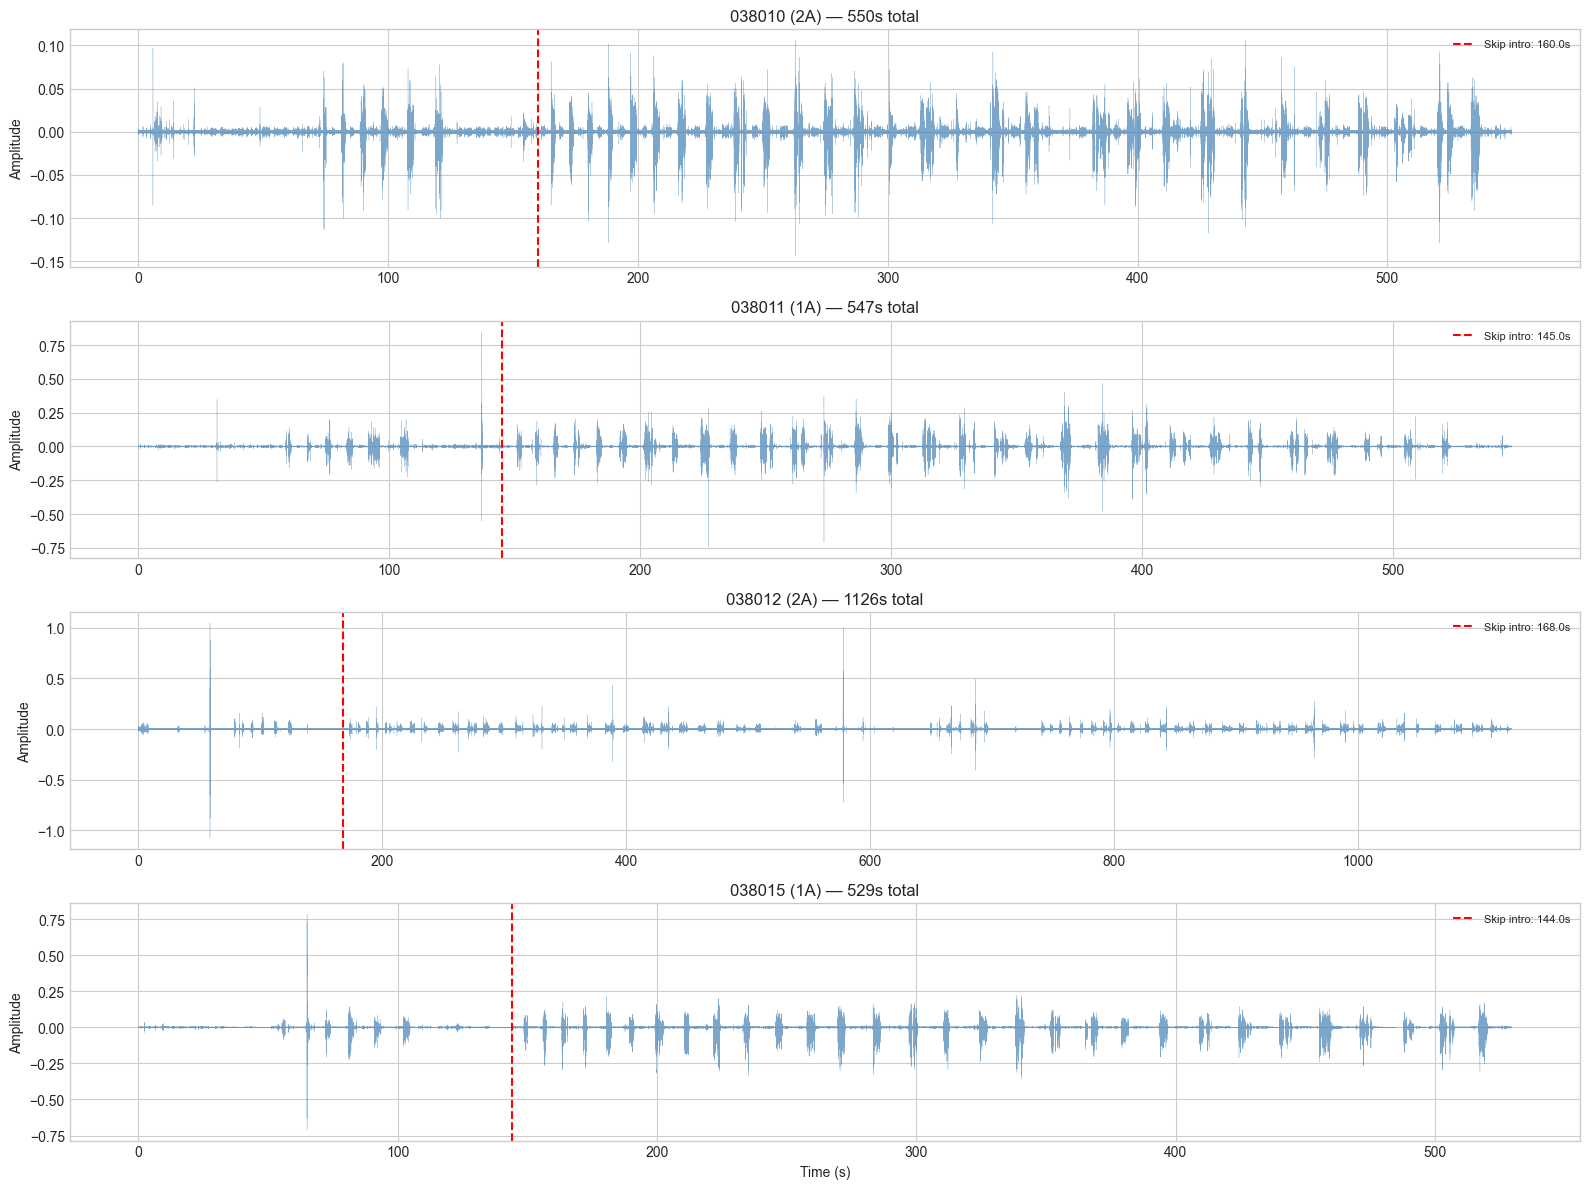

In [5]:
# Audio file overview — waveforms + skip-second markers
audio_files = DEFAULT_AUDIO_FILES
fig, axes = plt.subplots(len(audio_files), 1, figsize=(16, 3 * len(audio_files)))
if len(audio_files) == 1:
    axes = [axes]

for i, af in enumerate(audio_files):
    path = Path(config.audio_dir) / af.filename
    if not path.exists():
        axes[i].set_title(f"{af.participant_id} — FILE NOT FOUND: {af.filename}")
        continue

    y, sr = librosa.load(str(path), sr=16000, mono=True)
    duration = len(y) / sr
    times = np.arange(len(y)) / sr

    axes[i].plot(times, y, linewidth=0.2, alpha=0.7, color='steelblue')
    axes[i].axvline(af.skip_seconds, color='red', linestyle='--', linewidth=1.5,
                    label=f'Skip intro: {af.skip_seconds}s')
    axes[i].set_title(f"{af.participant_id} ({af.eit_version}) — {duration:.0f}s total")
    axes[i].set_ylabel('Amplitude')
    axes[i].legend(loc='upper right', fontsize=8)
    print(f"  {af.filename}: {duration:.1f}s ({duration/60:.1f} min), skip={af.skip_seconds}s")

axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.savefig(os.path.join(config.output_dir, 'audio_overview.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## Part A — Stimulus Extraction (One-time Bootstrap)

Before the alignment pipeline can run, it needs **reference audio** for each of the 30 stimulus sentences.
These are short WAV clips extracted from one of your EIT recordings by matching full-file ASR transcript
words against the known stimulus text.

**Run this section once**, then the resulting `data/stimulus_audio/stimulus_01.wav … stimulus_30.wav`
files are reused for all participants.

> **Tip:** Use the recording with the cleanest audio and fewest background artefacts as the reference source.

In [6]:
# ── Check whether stimulus audio already exists ──────────────────────────
stim_dir = Path(config.stimulus_alignment.stimulus_audio_dir)
existing = sorted(stim_dir.glob("stimulus_*.wav"))

if len(existing) == 30:
    print(f"Stimulus audio already extracted ({len(existing)} files in {stim_dir}) ✓")
    print("Skip to the next section unless you want to re-extract.")
else:
    print(f"Found {len(existing)}/30 stimulus files in {stim_dir}")
    print("Run the extraction cell below to generate them.")
    missing = set(range(1, 31)) - {int(f.stem.split('_')[1]) for f in existing}
    if missing:
        print(f"Missing indices: {sorted(missing)}")

Stimulus audio already extracted (30 files in data/stimulus_audio) ✓
Skip to the next section unless you want to re-extract.


In [7]:
# ── Extract stimulus reference audio ─────────────────────────────────────
# Choose the recording with the cleanest stimulus audio as reference source.
# 038011 (1A) is often a good choice.

REFERENCE_RECORDING = "038010_EIT-2A.mp3"
REFERENCE_SKIP_S = 160.0             # skip intro
FORCE_REEXTRACT = False              # set True to overwrite existing files

stim_dir = Path(config.stimulus_alignment.stimulus_audio_dir)
existing = sorted(stim_dir.glob("stimulus_*.wav"))

if len(existing) == 30 and not FORCE_REEXTRACT:
    print(f"Already have 30 stimulus files — skipping extraction.")
    print(f"Set FORCE_REEXTRACT = True to regenerate.")
else:
    ref_path = Path(config.audio_dir) / REFERENCE_RECORDING
    print(f"Extracting stimuli from: {ref_path}")
    print(f"Target directory:        {stim_dir}")

    extracted = extract_stimuli_from_recording(
        audio_path=str(ref_path),
        output_dir=str(stim_dir),
        skip_seconds=REFERENCE_SKIP_S,
        sentences=TARGET_SENTENCES,
        sample_rate=config.audio_io.sample_rate,
        padding_before_s=0.15,           # 150ms padding before each stimulus
        padding_after_s=0.15,            # 150ms padding after each stimulus
    )

    print(f"\nExtracted {len(extracted)}/30 stimulus files:")
    for stimulus in sorted(extracted, key=lambda s: s.sentence_id):
        print(f"  {stimulus.sentence_id:2d}. {stimulus.sentence_text[:50]:<50}  → stimulus_{stimulus.sentence_id:02d}.wav")


Already have 30 stimulus files — skipping extraction.
Set FORCE_REEXTRACT = True to regenerate.


---
## 4. Stage 1 — Audio Loading

Load each MP3, convert to 16kHz mono float32, skip the intro section (instrument setup + task instructions),
normalise peak amplitude to −3 dB, and optionally apply spectral-gating noise reduction.

Loading 038010 (038010_EIT-2A.mp3)... 389.6s @ 16000Hz  (2.5s)
Loading 038011 (038011_EIT-1A.mp3)... 402.0s @ 16000Hz  (1.9s)
Loading 038012 (038012_EIT-2A.mp3)... 957.5s @ 16000Hz  (3.7s)
Loading 038015 (038015_EIT-1A.mp3)... 385.4s @ 16000Hz  (1.7s)

Loaded 4/4 recordings ✓


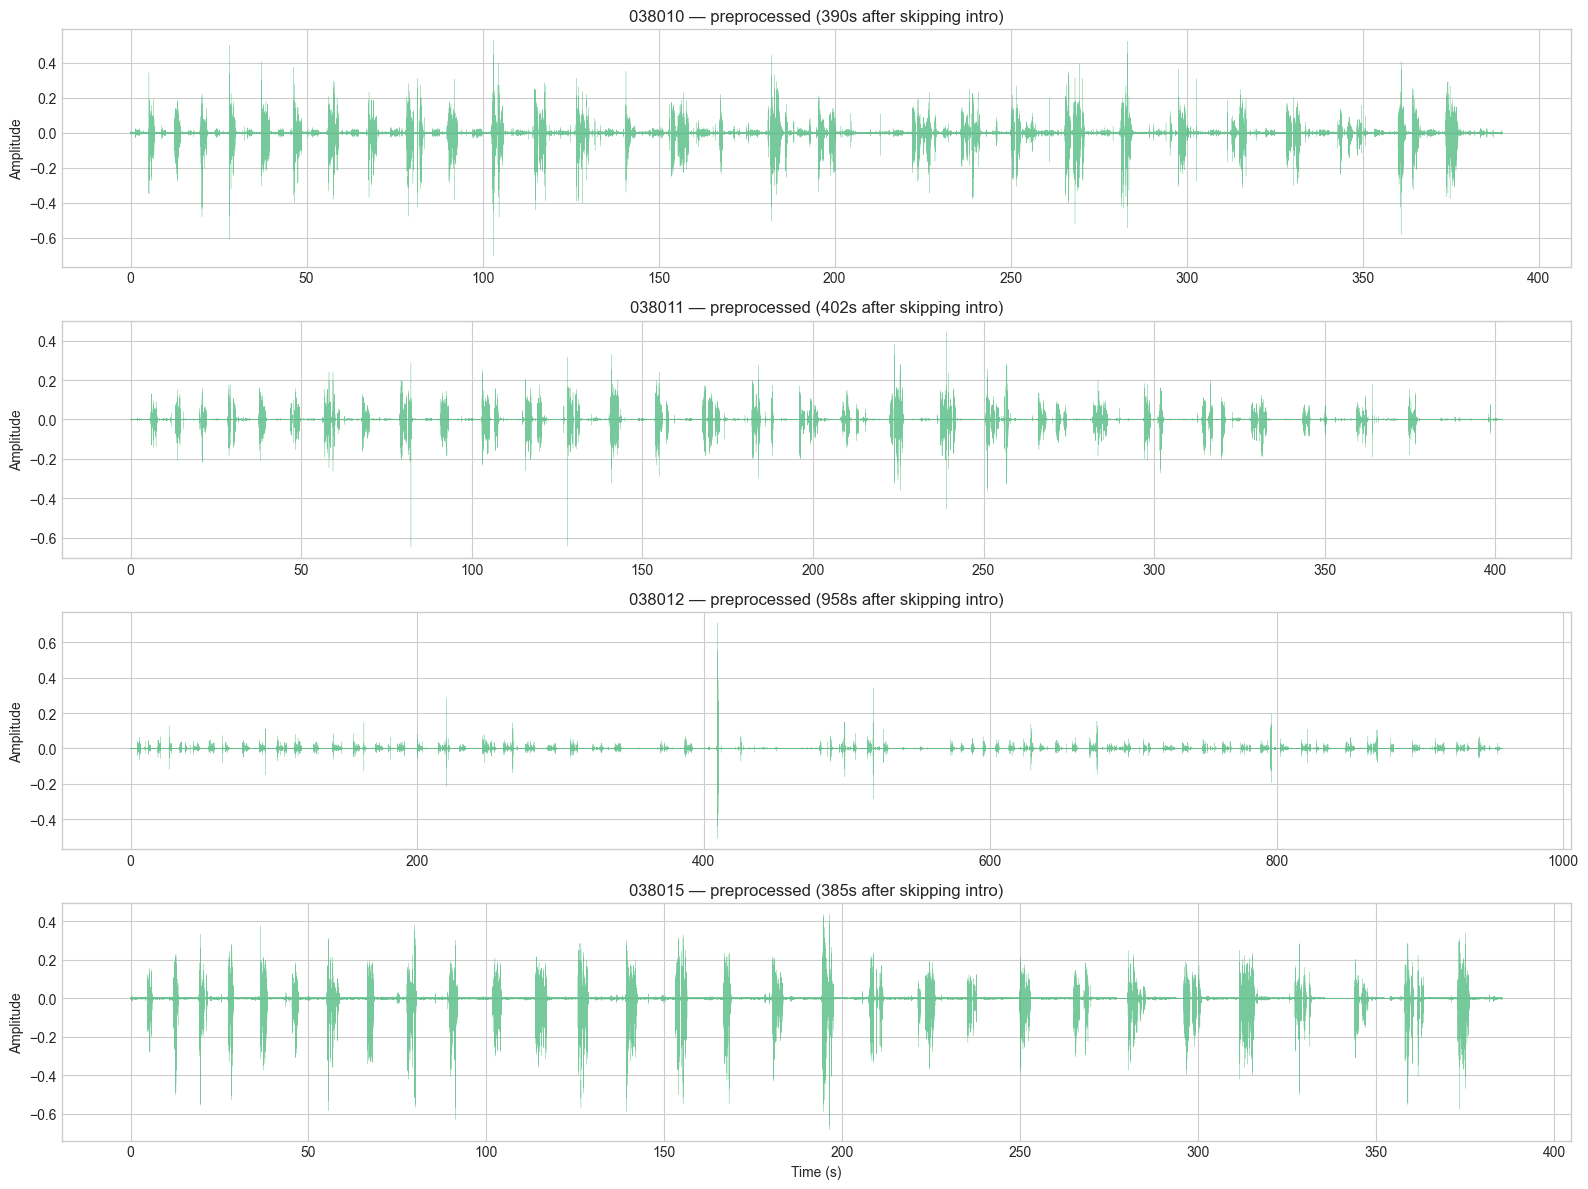

In [8]:
import time

recordings = {}   # participant_id → AudioData

for af in DEFAULT_AUDIO_FILES:
    audio_path = Path(config.audio_dir) / af.filename
    if not audio_path.exists():
        print(f"  SKIPPING {af.participant_id} — file not found: {audio_path}")
        continue

    print(f"Loading {af.participant_id} ({af.filename})...", end=" ", flush=True)
    t0 = time.time()
    rec = load_audio(str(audio_path), config=config.audio_io, skip_seconds=af.skip_seconds)
    recordings[af.participant_id] = rec
    print(f"{rec.duration_s:.1f}s @ {rec.sample_rate}Hz  ({time.time()-t0:.1f}s)")

print(f"\nLoaded {len(recordings)}/{len(DEFAULT_AUDIO_FILES)} recordings ✓")

# Waveform overview
fig, axes = plt.subplots(len(recordings), 1, figsize=(16, 3 * len(recordings)))
if len(recordings) == 1:
    axes = [axes]
for ax, (pid, rec) in zip(axes, recordings.items()):
    times = np.linspace(0, rec.duration_s, len(rec.waveform))
    ax.plot(times, rec.waveform, linewidth=0.2, alpha=0.7, color='mediumseagreen')
    ax.set_title(f"{pid} — preprocessed ({rec.duration_s:.0f}s after skipping intro)")
    ax.set_ylabel('Amplitude')
axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.savefig(os.path.join(config.output_dir, 'stage1_loaded_audio.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Stage 2 — Stimulus Alignment

Locate where each of the 30 stimulus sentences plays in the recording by matching the reference
stimulus audio files against the full recording.

**Three available methods:**

| Method | How it works | Best for |
|---|---|---|
| `cross_correlation` | Mel-spectrogram cross-correlation, peak finding | Clean audio, consistent level |
| `mfcc_cosine` | Sliding MFCC cosine similarity window | Noisy or level-variable audio |
| `fingerprint` | Spectral peak hash matching (Shazam-like) | Recordings with reverberation |

The cell below runs the method configured in `config.stimulus_alignment.method`.
The following cell compares all three methods side-by-side.

In [9]:
# Load stimulus reference audio
stim_dir = Path(config.stimulus_alignment.stimulus_audio_dir)
if not stim_dir.exists() or len(list(stim_dir.glob("stimulus_*.wav"))) == 0:
    raise RuntimeError(f"No stimulus audio in {stim_dir}. Run Part A (stimulus extraction) first.")

stimulus_audio = load_stimulus_audio(str(stim_dir), config.audio_io.sample_rate)
print(f"Loaded {len(stimulus_audio)} stimulus reference files")

# Run alignment for each participant
alignments = {}    # pid → AlignmentResult

for pid, rec in recordings.items():
    print(f"\n  Aligning {pid} (method={config.stimulus_alignment.method})...", end=" ", flush=True)
    t0 = time.time()
    alignment = align_stimuli(rec, stimulus_audio, config.stimulus_alignment)
    alignments[pid] = alignment
    detected = len(alignment.events)
    print(f"{detected}/30 stimuli detected in {time.time()-t0:.1f}s")

    # Show first few events
    for ev in alignment.events[:5]:
        print(f"    S{ev.sentence_id:02d}  start={ev.stimulus_start_s:.2f}s  end={ev.stimulus_end_s:.2f}s  "
              f"score={ev.confidence:.3f}  method={ev.method}")


Loaded 30 stimulus reference files

  Aligning 038010 (method=cross_correlation)... 30/30 stimuli detected in 1.4s
    S04  start=4.90s  end=6.56s  score=0.809  method=cross_correlation
    S03  start=19.17s  end=21.86s  score=1.250  method=cross_correlation
    S05  start=27.55s  end=29.86s  score=0.980  method=cross_correlation
    S06  start=41.66s  end=48.67s  score=1.106  method=cross_correlation
    S07  start=50.34s  end=58.53s  score=1.192  method=cross_correlation

  Aligning 038011 (method=cross_correlation)... 30/30 stimuli detected in 0.3s
    S30  start=37.41s  end=40.58s  score=0.779  method=cross_correlation
    S23  start=66.11s  end=84.64s  score=0.626  method=cross_correlation
    S11  start=69.12s  end=82.85s  score=0.752  method=cross_correlation
    S12  start=78.27s  end=84.61s  score=0.971  method=cross_correlation
    S19  start=79.68s  end=83.17s  score=0.606  method=cross_correlation

  Aligning 038012 (method=cross_correlation)... 30/30 stimuli detected in 0.

### 5a. Compare All Three Alignment Methods

Run all three methods on one participant and display a side-by-side comparison table + plot.

In [10]:
# Compare all 3 methods on the first available participant
COMPARE_PID = next(iter(recordings))
rec = recordings[COMPARE_PID]

print(f"Running all 3 alignment methods on {COMPARE_PID}...\n")

comparison = compare_all_methods(rec, stimulus_audio, config.stimulus_alignment)

# Summary table
print(f"{'Method':<20} {'Detected':>8} {'Mean score':>10} {'Events'}")
print("-" * 70)
for method_name, result in comparison.items():
    n = len(result.events)
    mean_score = np.mean([e.confidence for e in result.events]) if result.events else 0.0
    ev_preview = "  ".join(f"S{e.sentence_id}" for e in result.events[:6])
    print(f"  {method_name:<18} {n:>8}   {mean_score:>8.3f}   {ev_preview}{'...' if n > 6 else ''}")

# Quantitative comparison
compare_report = format_comparison_report(compare_alignment_methods(comparison))
print(f"\n{compare_report}")

# Store for downstream use
all_comparison_results = {COMPARE_PID: comparison}


Running all 3 alignment methods on 038010...

Method               Detected Mean score Events
----------------------------------------------------------------------
  cross_correlation        30      1.006   S4  S3  S5  S6  S7  S8...
  mfcc_cosine              30      0.000   S1  S2  S3  S4  S5  S6...
  fingerprint              30      0.942   S28  S22  S23  S26  S21  S29...

STIMULUS ALIGNMENT METHOD COMPARISON

--- CROSS_CORRELATION ---
  Detection rate: 100.0% (30/30)
  Confidence:     1.006 ± 0.210
  Range:          [0.461, 1.360]
  Ordered:        True

--- MFCC_COSINE ---
  Detection rate: 100.0% (30/30)
  Confidence:     0.000 ± 0.000
  Range:          [0.000, 0.000]
  Ordered:        True

--- FINGERPRINT ---
  Detection rate: 100.0% (30/30)
  Confidence:     0.942 ± 0.028
  Range:          [0.876, 0.979]
  Ordered:        False


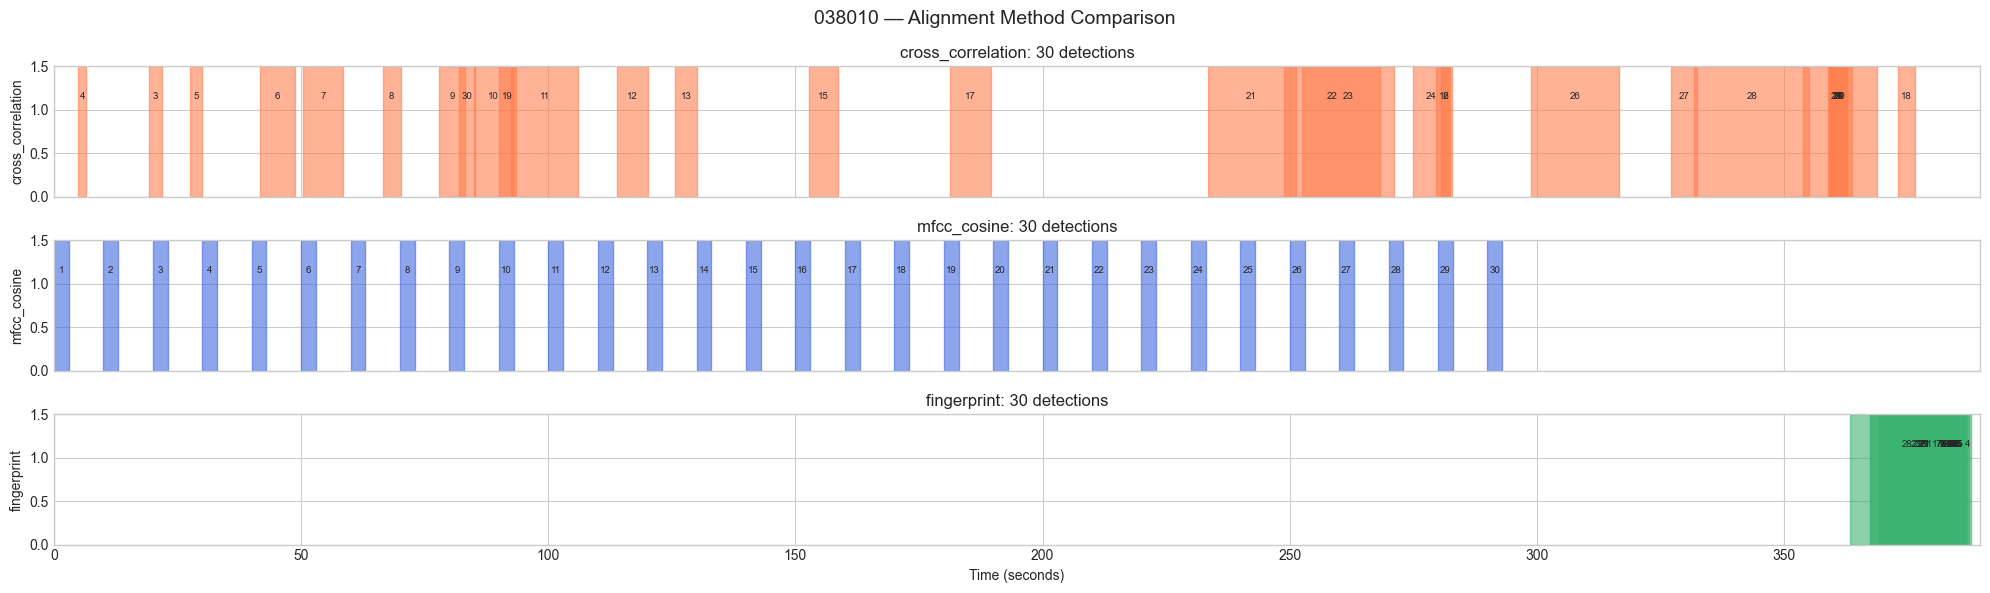


Green = detected stimulus events.  Each subplot is one alignment method.
Check that events cluster near the true stimulus positions.


In [11]:
# Plot alignment comparison — all 3 methods on one recording
fig = plot_alignment_comparison(
    comparison_results=comparison,
    recording_duration_s=recordings[COMPARE_PID].duration_s,
    title=f"{COMPARE_PID} — Alignment Method Comparison",
)
plt.savefig(os.path.join(config.output_dir, f'{COMPARE_PID}_alignment_comparison.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print("\nGreen = detected stimulus events.  Each subplot is one alignment method.")
print("Check that events cluster near the true stimulus positions.")

---
## 6. Stage 3 — Speech Detection (VAD — informational)

Silero VAD scans the full recording and labels every region with detectable vocal activity.

**Important architectural note:** VAD output is passed to Stage 4 *for counting/logging only*.
It is **not** used to determine response boundaries in this pipeline.

The recording contains exactly two voices:
- **Stimulus** — professionally recorded playback voice (identical across participants)
- **Response** — the participant repeating the stimulus

Because VAD cannot distinguish the two voices, using VAD segments as response boundaries
causes the ASR to sometimes receive stimulus audio instead of participant audio.
Stage 4 solves this by anchoring windows on the *stimulus timestamps* instead.


  VAD: 038010... 

Using cache found in /Users/tilakgupta/.cache/torch/hub/snakers4_silero-vad_master


30 speech segments  |  99.8s total speech  (4.2s)
  VAD: 038011... 

Using cache found in /Users/tilakgupta/.cache/torch/hub/snakers4_silero-vad_master


35 speech segments  |  107.8s total speech  (1.7s)
  VAD: 038012... 

Using cache found in /Users/tilakgupta/.cache/torch/hub/snakers4_silero-vad_master


71 speech segments  |  270.9s total speech  (3.6s)
  VAD: 038015... 

Using cache found in /Users/tilakgupta/.cache/torch/hub/snakers4_silero-vad_master


30 speech segments  |  97.1s total speech  (1.8s)


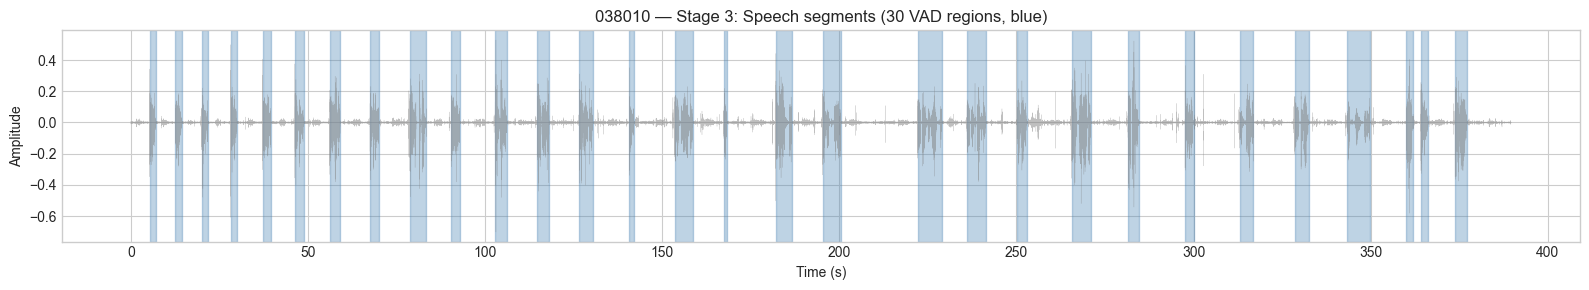

In [12]:
speech_segments = {}   # pid → list[SpeechSegment]

for pid, rec in recordings.items():
    print(f"  VAD: {pid}...", end=" ", flush=True)
    t0 = time.time()
    segs = detect_speech(rec, config.silence_detection)
    speech_segments[pid] = segs
    total_speech = sum(s.end_s - s.start_s for s in segs)
    print(f"{len(segs)} speech segments  |  {total_speech:.1f}s total speech  ({time.time()-t0:.1f}s)")

# Quick visualisation of one participant
demo_pid = next(iter(speech_segments))
demo_rec = recordings[demo_pid]
demo_segs = speech_segments[demo_pid]

fig, ax = plt.subplots(figsize=(16, 3))
times = np.linspace(0, demo_rec.duration_s, len(demo_rec.waveform))
ax.plot(times, demo_rec.waveform, linewidth=0.2, alpha=0.5, color='gray')
for s in demo_segs:
    ax.axvspan(s.start_s, s.end_s, alpha=0.35, color='steelblue')
ax.set_title(f"{demo_pid} — Stage 3: Speech segments ({len(demo_segs)} VAD regions, blue)")
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude')
plt.tight_layout()
plt.show()

---
## 7. Stages 4 + 5 — Response Windows & VAD Boundary Refinement

### Stage 4 — Hybrid Stimulus-Anchor + VAD Response Extraction

Each response window is found using a two-step strategy:

**Step 1 — Safe search zone from stimulus timestamps**
```
zone_start = stimulus_end_i        + post_stimulus_gap_s  (0.3 s)
zone_end   = stimulus_start_(i+1)  - pre_stimulus_gap_s   (0.3 s)
```
The gaps absorb small timestamp errors from the alignment stage and keep any
residual stimulus audio out of the zone.

**Step 2 — First VAD speech segment inside the zone**

Within the zone, the first actual voiced segment detected by Silero VAD becomes
the response anchor. Adjacent segments closer than `merge_gap_s` (1.0 s) are
merged in case the learner pauses mid-sentence.

Hard constraints are then applied:
- `min_response_duration_s` = 0.8 s  — reject very short fragments
- `max_response_duration_s` = 6.0 s  — cap unusually long responses

If **no** VAD segment is found inside the zone the entry is marked as no-response.
This is robust against inaccurate stimulus timestamps: even if a timestamp slips
by ~0.3 s, the zone gap still keeps stimulus audio out, and only real participant
speech can serve as the anchor.

### Stage 5 — VAD Boundary Refinement

Within each extracted segment, frame-level VAD (30 ms frames) trims silence from
the start and end. The expansion window is **clamped at `stimulus_end_s`** so it
can never back into stimulus audio regardless of how the boundaries shift.


In [13]:
response_windows = {}   # pid → list[ResponseSegment]

for pid, rec in recordings.items():
    events = alignments[pid].events
    segs   = speech_segments[pid]

    # Stage 4: build windows
    raw_windows = build_response_windows(events, segs, config.response_window)

    # Stage 5: refine boundaries
    refined = refine_boundaries(raw_windows, rec, config.vad_refinement)
    response_windows[pid] = refined

    n_speech = sum(1 for r in refined if r.response_end_s > 0)
    no_resp  = sum(1 for r in refined if r.response_end_s == 0)
    print(f"  {pid}: {len(refined)} windows  |  {n_speech} with speech  |  {no_resp} no-response")

print(f"\nResponse windows built for {len(response_windows)} participants ✓")

Using cache found in /Users/tilakgupta/.cache/torch/hub/snakers4_silero-vad_master


  038010: 30 windows  |  7 with speech  |  23 no-response


Using cache found in /Users/tilakgupta/.cache/torch/hub/snakers4_silero-vad_master


  038011: 30 windows  |  5 with speech  |  25 no-response


Using cache found in /Users/tilakgupta/.cache/torch/hub/snakers4_silero-vad_master


  038012: 30 windows  |  5 with speech  |  25 no-response
  038015: 30 windows  |  6 with speech  |  24 no-response

Response windows built for 4 participants ✓


Using cache found in /Users/tilakgupta/.cache/torch/hub/snakers4_silero-vad_master


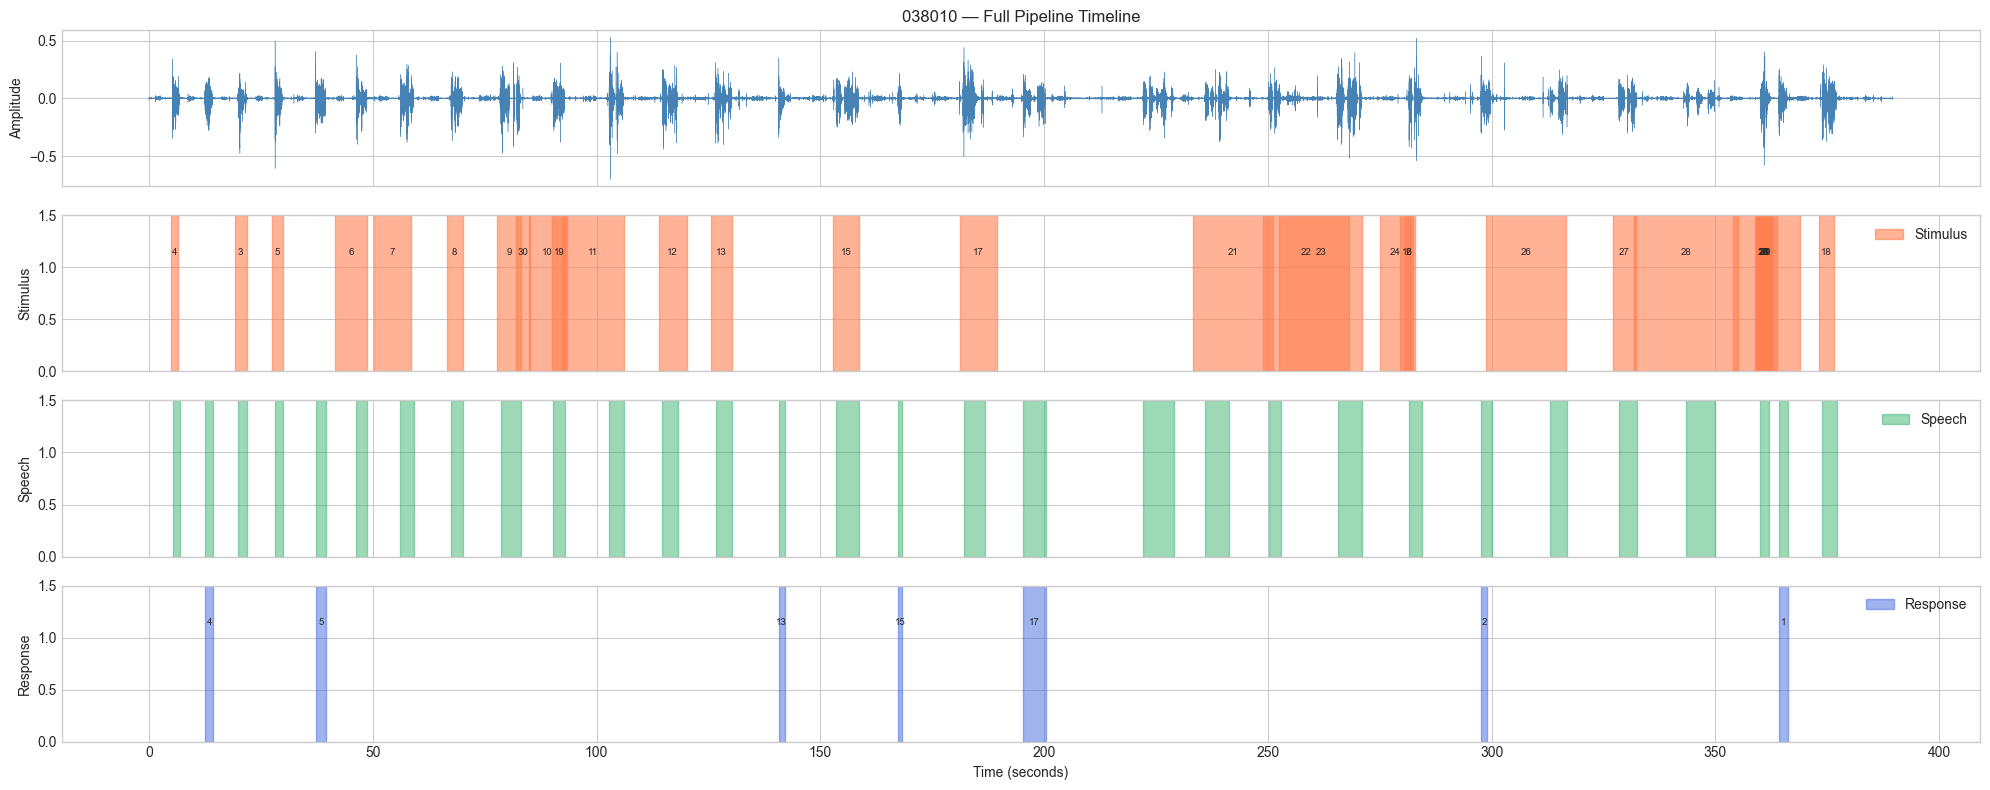

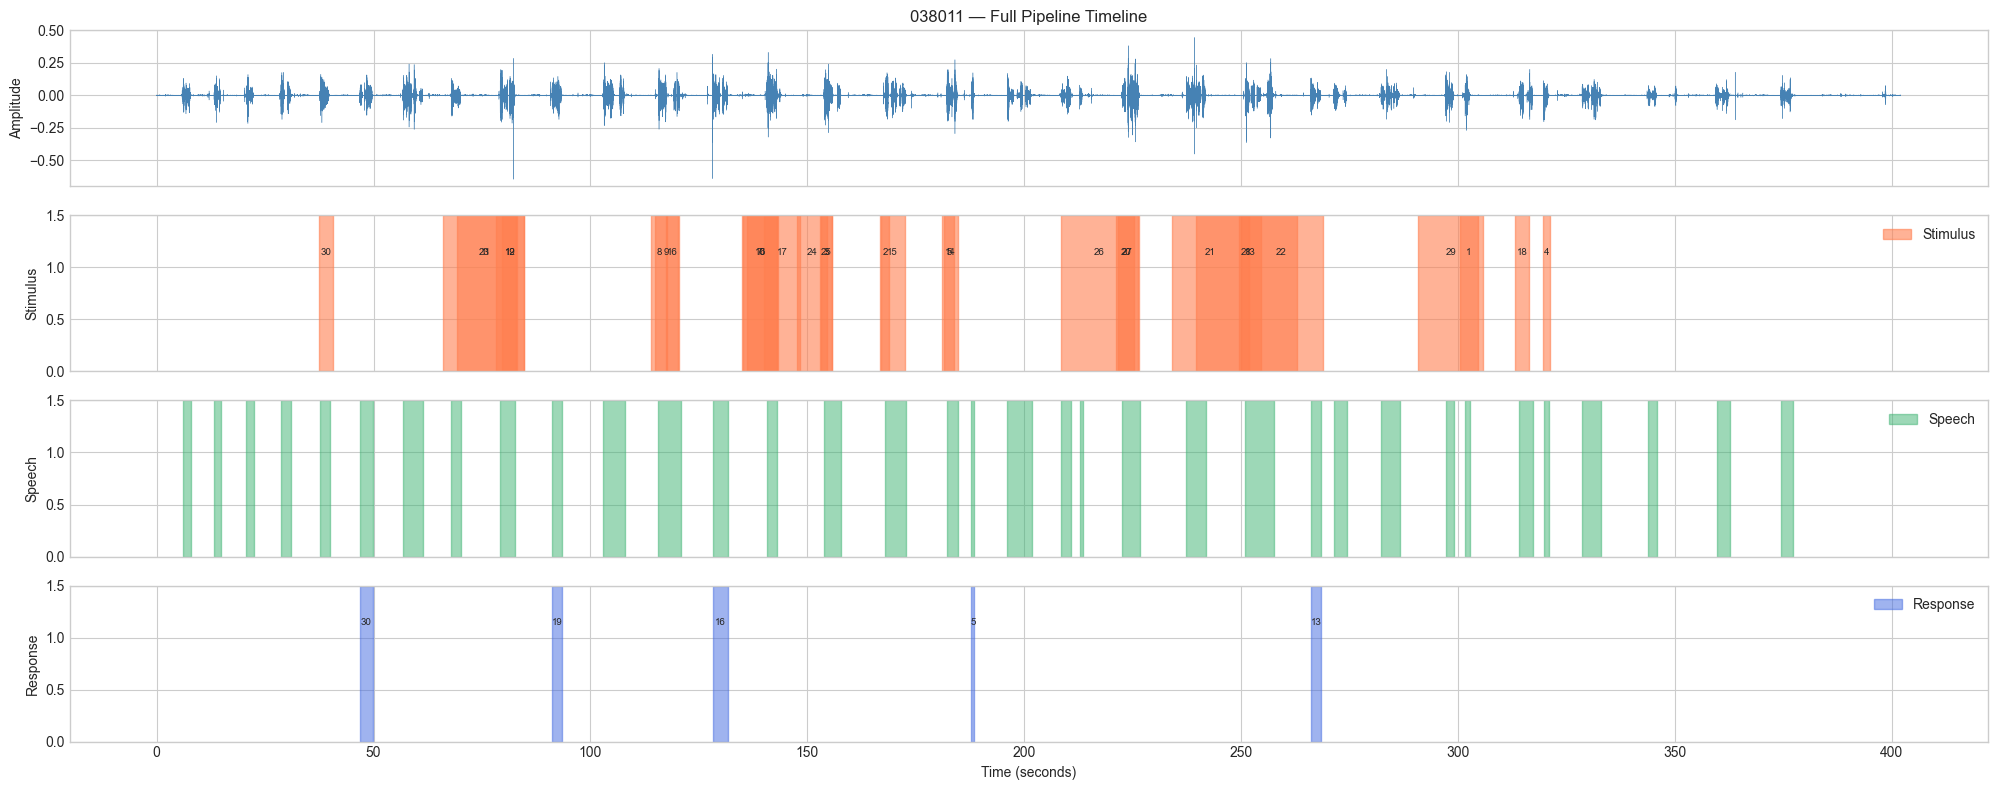

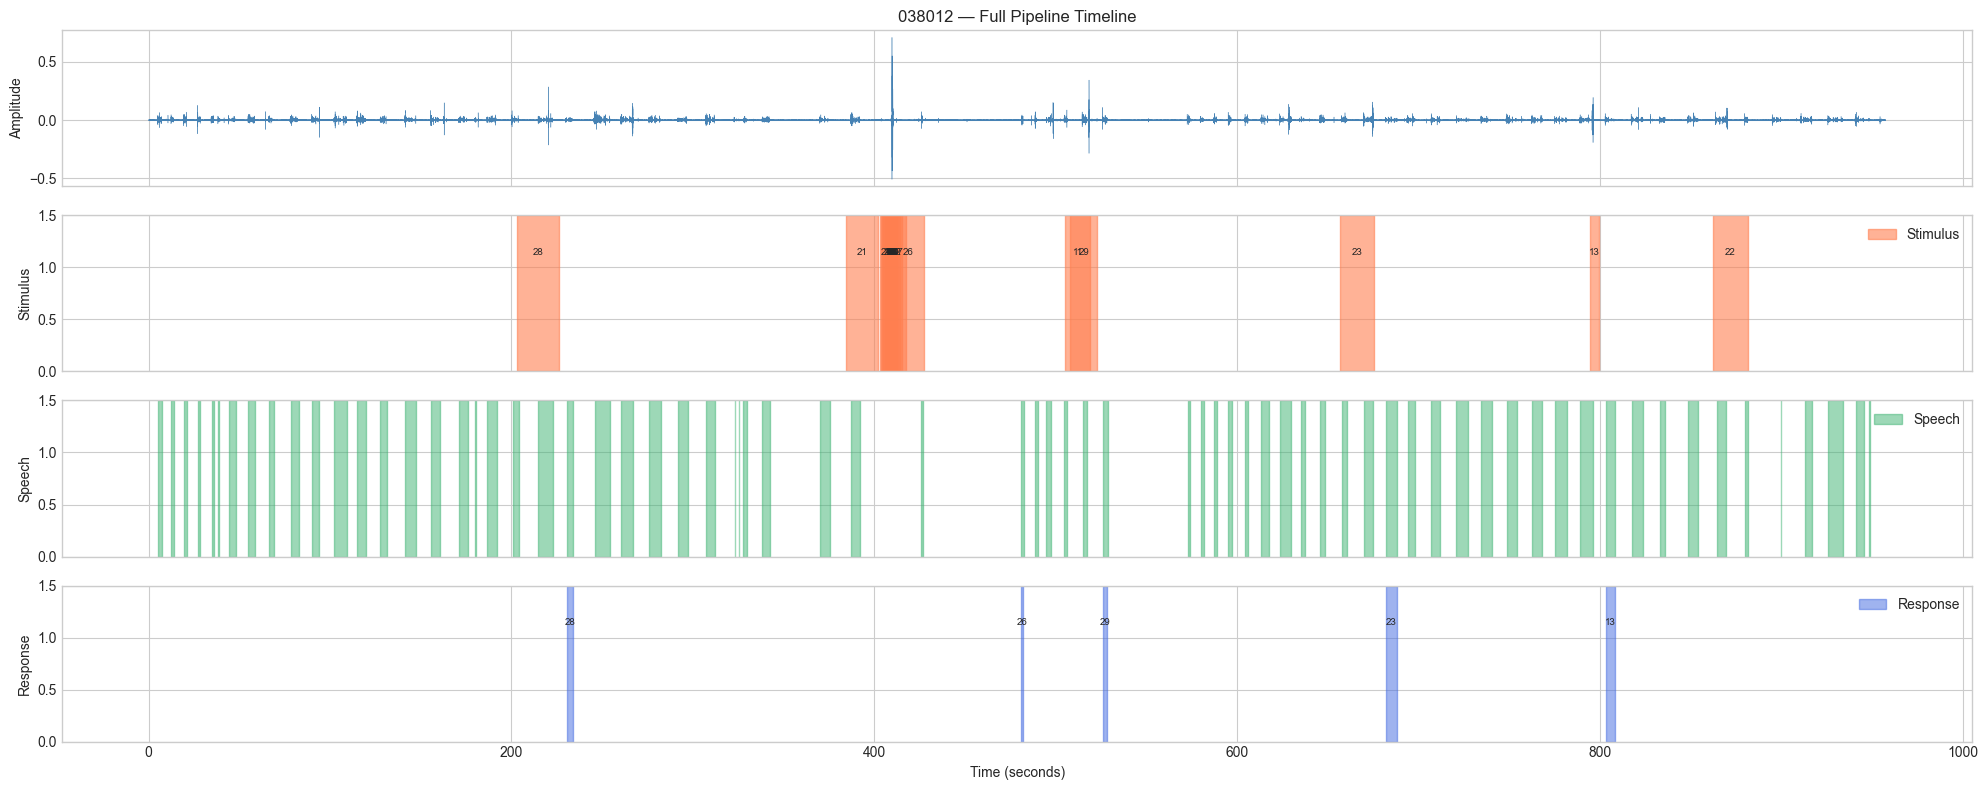

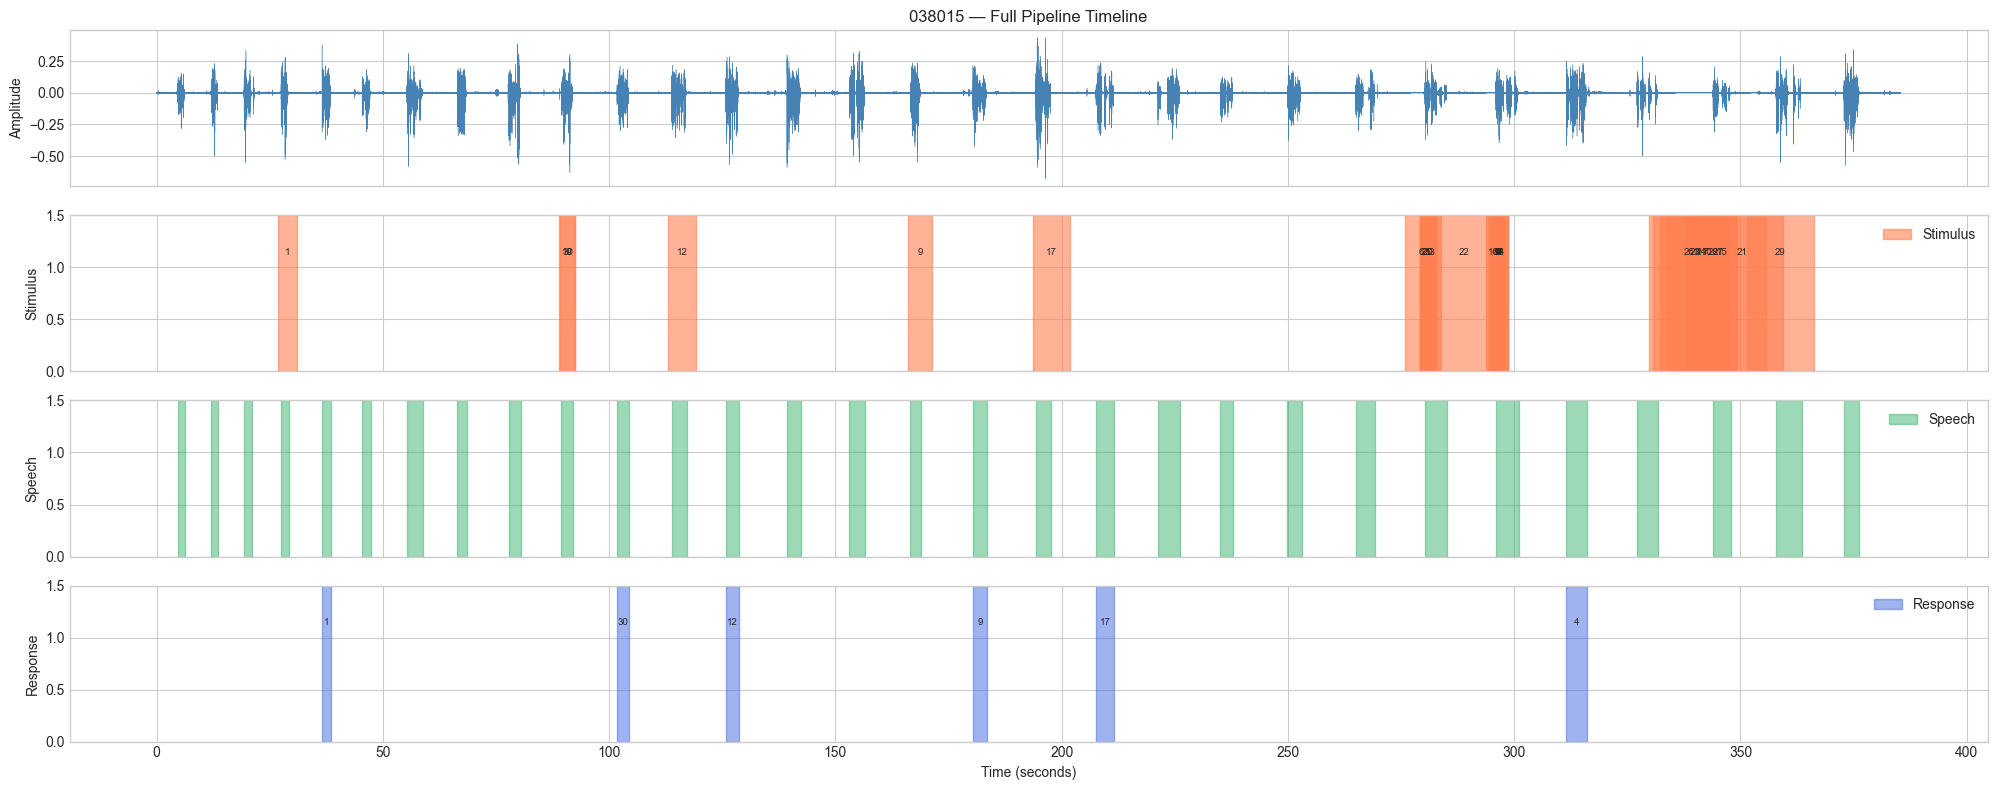

In [14]:
# Full timeline view for each participant
for pid, rec in recordings.items():
    fig = plot_timeline(
        recording=rec,
        stimulus_events=alignments[pid].events,
        speech_segments=speech_segments[pid],
        responses=response_windows[pid],
        title=f"{pid} — Full Pipeline Timeline",
    )
    plt.savefig(os.path.join(config.output_dir, f'{pid}_timeline.png'), dpi=150, bbox_inches='tight')
    plt.show()

---
## 8. Stage 6 — Diarization Filter (Disabled)

Diarization is **disabled** by default and not recommended for this dataset.

**Why:** EIT recordings contain exactly two voices (stimulus playback + participant).
Diarization models trained on conversational multi-speaker audio are unreliable in
this setting and often fragment or misclassify turns.  The stimulus-anchored Stage 4
windows already provide a clean speaker separation without diarization.

To enable diarization (not recommended):
```python
config.diarization.enabled = True
config.diarization.hf_token = "hf_xxxx"
```


In [15]:
HF_TOKEN = os.environ.get("HUGGINGFACE_TOKEN", "")   # or paste directly: "hf_xxxx"

if HF_TOKEN:
    config.diarization.enabled = True
    config.diarization.hf_token = HF_TOKEN
    config.diarization.num_speakers = 2
    print(f"Diarization enabled. HF token: {HF_TOKEN[:8]}…")
else:
    config.diarization.enabled = False
    print("No HF token — diarization disabled.")
    print("Set HUGGINGFACE_TOKEN env var or paste token above to enable.")

diarization_results = {}   # pid → (filtered_windows, diar_result) or None

if config.diarization.enabled:
    for pid, rec in recordings.items():
        print(f"\n  Diarizing {pid}...", end=" ", flush=True)
        try:
            t0 = time.time()
            filtered, diar_result = filter_by_diarization(
                response_windows[pid], rec, config.diarization,
            )
            response_windows[pid] = filtered
            diarization_results[pid] = diar_result
            print(f"done in {time.time()-t0:.1f}s  |  response speaker: {diar_result.response_speaker}")
        except Exception as e:
            print(f"FAILED: {e}")
else:
    print("Stage 6 skipped.")

No HF token — diarization disabled.
Set HUGGINGFACE_TOKEN env var or paste token above to enable.
Stage 6 skipped.


---
## 9. Stage 7 — ASR Transcription

Transcribes only the learner response windows using the configured Whisper backend.

- **First pass:** greedy decoding (temperature = 0) for deterministic output
- **Multi-pass:** if `avg_log_prob < low_confidence_threshold`, retry with `temperature = 0.2`
- **Word timestamps:** available for downstream analysis when `word_timestamps = true`

In [16]:
transcriptions = {}   # pid → list[TranscriptionResult]

for pid, rec in recordings.items():
    windows = response_windows[pid]
    n_speech = sum(1 for w in windows if w.response_end_s > 0)
    print(f"\nTranscribing {pid} ({n_speech}/{len(windows)} windows with speech)...")

    t0 = time.time()
    results = transcribe_responses(windows, rec, config.asr)
    transcriptions[pid] = results
    elapsed = time.time() - t0

    n_text   = sum(1 for r in results if r.transcript != "[no response]")
    n_retry  = sum(1 for r in results if r.pass_number == 2)
    avg_prob = np.mean([r.avg_log_prob for r in results if r.transcript != "[no response]"] or [0])
    print(f"  → {n_text}/30 with text | {n_retry} multi-pass retries | avg_logprob={avg_prob:.3f} | {elapsed:.1f}s")

print(f"\nASR complete for {len(transcriptions)} participants ✓")


Transcribing 038010 (7/30 windows with speech)...


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


  → 7/30 with text | 0 multi-pass retries | avg_logprob=-0.504 | 7.9s

Transcribing 038011 (5/30 windows with speech)...
  → 5/30 with text | 0 multi-pass retries | avg_logprob=-0.345 | 2.6s

Transcribing 038012 (5/30 windows with speech)...
  → 5/30 with text | 0 multi-pass retries | avg_logprob=-0.832 | 4.1s

Transcribing 038015 (6/30 windows with speech)...
  → 6/30 with text | 0 multi-pass retries | avg_logprob=-0.465 | 3.5s

ASR complete for 4 participants ✓


In [17]:
# Preview raw ASR results for first participant
demo_pid = next(iter(transcriptions))
print(f"Participant {demo_pid} — ASR results (first 10):")
print("=" * 70)
for r in transcriptions[demo_pid][:10]:
    stim = TARGET_SENTENCES[r.sentence_id - 1]
    flag = " ⚠ low conf" if r.avg_log_prob < config.asr.low_confidence_threshold else ""
    print(f"  [{r.sentence_id:2d}] S: {stim[:50]}")
    print(f"       T: {r.transcript}{flag}")
    print(f"       logprob={r.avg_log_prob:.3f}  pass={r.pass_number}")

Participant 038010 — ASR results (first 10):
  [ 4] S: El se ducha cada mañana
       T: El libro está en la mesa.
       logprob=-0.243  pass=1
  [ 3] S: El carro lo tiene Pedro
       T: [no response]
       logprob=0.000  pass=1
  [ 5] S: ¿Qué dice usted que va a hacer hoy?
       T: Y esto es el que va a ser hoy.
       logprob=-0.673  pass=1
  [ 6] S: Dudo que sepa manejar muy bien
       T: [no response]
       logprob=0.000  pass=1
  [ 7] S: Las calles de esta ciudad son muy anchas
       T: [no response]
       logprob=0.000  pass=1
  [ 8] S: Puede que llueva mañana todo el día
       T: [no response]
       logprob=0.000  pass=1
  [ 9] S: Las casas son muy bonitas pero caras
       T: [no response]
       logprob=0.000  pass=1
  [30] S: Hay mucha gente que no toma nada para el desayuno
       T: [no response]
       logprob=0.000  pass=1
  [10] S: Me gustan las películas que acaban bien
       T: [no response]
       logprob=0.000  pass=1
  [19] S: Me gustaría que empezara a h

---
## 10. Stage 8 — Stimulus Leakage Check

Compares each response transcript against the corresponding stimulus text.

| Similarity | Action |
|---|---|
| ≥ `similarity_threshold` (0.85) | **Flagged** — marked in output, low confidence |
| ≥ `discard_threshold` (0.90) | **Discarded** — transcript replaced with `[stimulus echo — discarded]` |

A high similarity score usually means:
- The stimulus audio leaked into the microphone (ASR transcribed stimulus, not participant)
- The response window was misaligned and captured stimulus audio

With stimulus-anchored windows (Stage 4) this should be rare.  The check acts as a
safety net for edge cases.


In [18]:
leakage_flags = {}   # pid → list[LeakageFlag]

for pid, trans in transcriptions.items():
    flags = check_leakage(trans, config.leakage_check)
    leakage_flags[pid] = flags
    flagged = [f for f in flags if f.flagged]
    print(f"  {pid}: {len(flagged)}/{len(flags)} flagged for stimulus leakage")
    for f in flagged:
        print(f"    S{f.sentence_id:02d}  similarity={f.similarity_score:.3f}  '{f.transcript[:50]}'")

print(f"\nLeakage check complete ✓")

  038010: 0/30 flagged for stimulus leakage
  038011: 0/30 flagged for stimulus leakage
  038012: 0/30 flagged for stimulus leakage
  038015: 0/30 flagged for stimulus leakage

Leakage check complete ✓


---
## 11. Stage 9 — Output Assembly

Assembles a `ParticipantOutput` per participant and exports to JSON, CSV, and Excel.

In [19]:
outputs = []   # list[ParticipantOutput]
af_map = {af.participant_id: af for af in DEFAULT_AUDIO_FILES}

for pid in transcriptions:
    af = af_map[pid]
    out = assemble_results(
        participant_id=pid,
        eit_version=af.eit_version,
        responses=response_windows[pid],
        transcriptions=transcriptions[pid],
        leakage_flags=leakage_flags[pid],
    )
    outputs.append(out)

# Export each participant's results
for out in outputs:
    export_all(out, config.output_dir, config.output)

print(f"Exported results for {len(outputs)} participants to: {config.output_dir}/")

# Preview final results
for out in outputs:
    flagged  = sum(1 for r in out.segments if r.flagged)
    no_resp  = sum(1 for r in out.segments if r.transcript == "[no response]")
    avg_prob = np.mean([r.avg_log_prob for r in out.segments if r.transcript != "[no response]"] or [0])
    print(f"\n  {out.participant_id} ({out.eit_version}): avg_logprob={avg_prob:.3f}  "
          f"flagged={flagged}  no-response={no_resp}")

Exported results for 4 participants to: output/

  038010 (2A): avg_logprob=-0.504  flagged=0  no-response=23

  038011 (1A): avg_logprob=-0.345  flagged=0  no-response=25

  038012 (2A): avg_logprob=-0.832  flagged=0  no-response=25

  038015 (1A): avg_logprob=-0.465  flagged=0  no-response=24


---
## 12. Full Transcription Results

Complete per-participant output table.

In [20]:
for out in outputs:
    print(f"\n{'='*90}")
    print(f"PARTICIPANT {out.participant_id} ({out.eit_version})")
    print(f"{'='*90}")
    print(f"{'#':>3}  {'Stimulus':<52} {'Transcript':<38} {'LogP':>6} {'Lk':>3}")
    print('-' * 110)
    for r in out.segments:
        stim  = r.stimulus_text[:50] + '..' if len(r.stimulus_text) > 52 else r.stimulus_text
        trans = r.transcript[:36] + '..'    if len(r.transcript) > 38    else r.transcript
        lk    = ' ⚠' if r.flagged else ''
        print(f"{r.sentence_id:3d}  {stim:<52} {trans:<38} {r.avg_log_prob:>6.3f} {lk}")


PARTICIPANT 038010 (2A)
  #  Stimulus                                             Transcript                               LogP  Lk
--------------------------------------------------------------------------------------------------------------
  1  Quiero cortarme el pelo                              El libro que está en la mesa.          -0.244 
  2  El libro está en la mesa                             Después de llegar.                     -0.420 
  3  El carro lo tiene Pedro                              [no response]                           0.000 
  4  El se ducha cada mañana                              El libro está en la mesa.              -0.243 
  5  ¿Qué dice usted que va a hacer hoy?                  Y esto es el que va a ser hoy.         -0.673 
  6  Dudo que sepa manejar muy bien                       [no response]                           0.000 
  7  Las calles de esta ciudad son muy anchas             [no response]                           0.000 
  8  Puede que llueva

---
## 13. Evaluation & Metrics

Per-participant pipeline quality metrics plus a side-by-side comparison of the three
alignment methods.


038010:
EIT PIPELINE METRICS REPORT
Method: cross_correlation

--- Stimulus Alignment ---
  Detected:   30 / 30
  Confidence: 1.006 ± 0.210

--- Response Windows ---
  With speech:  7
  No speech:    23
  Avg duration: 2.10s

--- Transcription ---
  Avg log prob:     -0.504
  Avg no-speech:    0.197

--- Quality ---
  Leakage flagged:  0
  Processing time:  7.9s

038011:
EIT PIPELINE METRICS REPORT
Method: cross_correlation

--- Stimulus Alignment ---
  Detected:   30 / 30
  Confidence: 0.822 ± 0.164

--- Response Windows ---
  With speech:  5
  No speech:    25
  Avg duration: 2.31s

--- Transcription ---
  Avg log prob:     -0.345
  Avg no-speech:    0.108

--- Quality ---
  Leakage flagged:  0
  Processing time:  2.6s

038012:
EIT PIPELINE METRICS REPORT
Method: cross_correlation

--- Stimulus Alignment ---
  Detected:   30 / 30
  Confidence: 1.185 ± 0.424

--- Response Windows ---
  With speech:  5
  No speech:    25
  Avg duration: 3.67s

--- Transcription ---
  Avg log prob:    

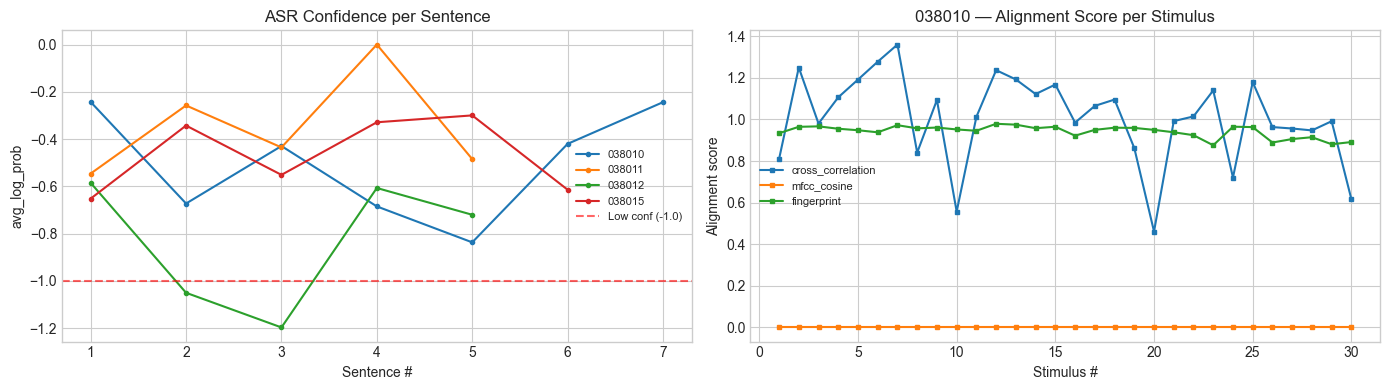

In [21]:
# Per-participant metrics
for pid in transcriptions:
    metrics = compute_metrics(
        alignment=alignments[pid],
        responses=response_windows[pid],
        transcriptions=transcriptions[pid],
        leakage_flags=leakage_flags[pid],
    )
    print(f"\n{pid}:")
    print(format_metrics_report(metrics))

# Confidence distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for pid, trans in transcriptions.items():
    probs = [r.avg_log_prob for r in trans if r.transcript != "[no response]"]
    axes[0].plot(range(1, len(probs)+1), probs, marker='o', markersize=3, label=pid)

axes[0].axhline(config.asr.low_confidence_threshold, color='red', linestyle='--',
                alpha=0.6, label=f'Low conf ({config.asr.low_confidence_threshold})')
axes[0].set_xlabel('Sentence #')
axes[0].set_ylabel('avg_log_prob')
axes[0].set_title('ASR Confidence per Sentence')
axes[0].legend(fontsize=8)

# Alignment score distribution per method (on COMPARE_PID)
for method_name, result in comparison.items():
    scores = [e.confidence for e in result.events]
    axes[1].plot(range(1, len(scores)+1), scores, marker='s', markersize=3, label=method_name)

axes[1].set_xlabel('Stimulus #')
axes[1].set_ylabel('Alignment score')
axes[1].set_title(f'{COMPARE_PID} — Alignment Score per Stimulus')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(config.output_dir, 'evaluation_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## 14. Interactive Segment Listening

Play back individual response segments to quickly audit transcription quality.

In [22]:
# Listen to response segments for a specific participant
LISTEN_PID = next(iter(recordings))

listen_to_segments(
    responses=response_windows[LISTEN_PID],
    recording=recordings[LISTEN_PID],
)

Sentence 4: 12.6s - 14.3s (duration: 1.68s)


Sentence 3: [no response]
Sentence 5: 37.2s - 39.6s (duration: 2.37s)


Sentence 6: [no response]
Sentence 7: [no response]
Sentence 8: [no response]
Sentence 9: [no response]
Sentence 30: [no response]
Sentence 10: [no response]
Sentence 19: [no response]
Sentence 11: [no response]
Sentence 12: [no response]
Sentence 13: 140.7s - 142.0s (duration: 1.35s)


Sentence 15: 167.3s - 168.3s (duration: 0.99s)


Sentence 17: 195.3s - 200.4s (duration: 5.13s)


Sentence 21: [no response]
Sentence 22: [no response]
Sentence 23: [no response]
Sentence 24: [no response]
Sentence 16: [no response]
Sentence 2: 297.7s - 299.0s (duration: 1.32s)


Sentence 26: [no response]
Sentence 27: [no response]
Sentence 28: [no response]
Sentence 29: [no response]
Sentence 14: [no response]
Sentence 20: [no response]
Sentence 25: [no response]
Sentence 1: 364.3s - 366.1s (duration: 1.86s)


Sentence 18: [no response]


---
## 15. Using the `EITPipeline` Runner (Batch)

`EITPipeline` wraps all 9 stages into a single call.  Useful for batch processing without
stepping through each stage manually.

In [23]:
# ── One-shot batch pipeline ────────────────────────────────────────────────
# Equivalent to running sections 4-11 above in one call.
# Results are saved to config.output_dir automatically.

# Add audio files to config so process_all() can find them
config.audio_files = DEFAULT_AUDIO_FILES

pipeline = EITPipeline(config)

# Load stimulus references (must run stimulus extraction first)
if Path(config.stimulus_alignment.stimulus_audio_dir).exists() and \
   len(list(Path(config.stimulus_alignment.stimulus_audio_dir).glob("stimulus_*.wav"))) == 30:

    pipeline.load_stimulus_references()

    # Process all participants — returns list of result dicts
    all_results = pipeline.process_all()

    # Summary
    print(f"\nBatch pipeline complete — {len(all_results)} participants processed")
    for result in all_results:
        if "error" in result:
            print(f"  {result['participant_id']}: ERROR — {result['error']}")
        else:
            m = result.get('metrics')
            if m:
                print(f"  {result['participant_id']}: {m.stimuli_detected}/30 stimuli  |  "
                      f"{m.responses_with_speech}/30 with speech  |  "
                      f"avg_logprob={m.avg_log_prob:.3f}")
else:
    print("Stimulus audio not yet extracted — run Part A first, then retry.")
    print(f"Expected: {config.stimulus_alignment.stimulus_audio_dir}/stimulus_01.wav … stimulus_30.wav")

Using cache found in /Users/tilakgupta/.cache/torch/hub/snakers4_silero-vad_master
Using cache found in /Users/tilakgupta/.cache/torch/hub/snakers4_silero-vad_master
Using cache found in /Users/tilakgupta/.cache/torch/hub/snakers4_silero-vad_master
Using cache found in /Users/tilakgupta/.cache/torch/hub/snakers4_silero-vad_master
Using cache found in /Users/tilakgupta/.cache/torch/hub/snakers4_silero-vad_master
Using cache found in /Users/tilakgupta/.cache/torch/hub/snakers4_silero-vad_master
Using cache found in /Users/tilakgupta/.cache/torch/hub/snakers4_silero-vad_master
Using cache found in /Users/tilakgupta/.cache/torch/hub/snakers4_silero-vad_master



Batch pipeline complete — 4 participants processed
  038010: 30/30 stimuli  |  7/30 with speech  |  avg_logprob=-0.504
  038011: 30/30 stimuli  |  5/30 with speech  |  avg_logprob=-0.345
  038012: 30/30 stimuli  |  5/30 with speech  |  avg_logprob=-0.832
  038015: 30/30 stimuli  |  6/30 with speech  |  avg_logprob=-0.465


---
## 16. Discussion & Future Work

### Architecture Comparison

| Aspect | Legacy (`autoeit`) | New (`eit_pipeline`) |
|---|---|---|
| Segment strategy | Energy VAD + 1kHz tone | Stimulus audio fingerprinting |
| No-response rate | ~64% on first run | Depends on alignment quality |
| Alignment methods | 1 | 3 (cross-correlation, MFCC cosine, fingerprint) |
| Stimulus leakage | Not detected | Flagged by leakage check |
| Diarization | `pyannote` (phase 2) | Optional stage 6 |
| Config system | YAML → single flat config | YAML → typed dataclasses |
| Output formats | Excel only | JSON + CSV + Excel |
| Tests | 0 | 26 unit tests |

### Alignment Method Trade-offs

- **`cross_correlation`** is fastest and works well in clean recordings.  Sensitive to level changes.
- **`mfcc_cosine`** is more robust to gain changes but slower (sliding window).
- **`fingerprint`** is most robust to reverberation and background noise; uses spectral peak hashing.

### Known Limitations

1. **Stimulus audio extraction accuracy** — The quality of `data/stimulus_audio/` files directly
   determines alignment quality.  Manually verify a few extracted files.
2. **No ground-truth timing** — We cannot measure alignment precision without manually labelled onset times.
   Use the alignment comparison (section 5a) to cross-validate methods.
3. **Whisper disfluency bias** — Whisper tends to "clean up" learner errors.  The EIT-specific initial
   prompt and multi-pass transcription reduce but do not eliminate this.

### Roadmap

1. **Fine-tuned model** — Train a domain-adapted Whisper on verified EIT transcripts to improve
   disfluency preservation and L2-accent robustness.
2. **DTW alignment** — Replace cross-correlation with Dynamic Time Warping for better tolerance of
   tempo variation when the stimulus plays at different speeds across recordings.
3. **Automatic scoring** — Extend pipeline to compute 0–4 EIT rubric scores based on edit distance
   from the stimulus + fluency markers.
4. **Benchmark dataset** — Manually label 2–3 recordings with ground-truth onset times to enable
   quantitative evaluation of each alignment method.